# Mini-projet ML — Prédiction du prix des maisons (House Prices)

**Objectif.** Construire un modèle de Machine Learning de **régression supervisée** capable de prédire le **prix de vente d’une maison** à partir de variables immobilières structurées (caractéristiques du logement, du terrain et de l’environnement).

**Variable cible.** `SalePrice` (prix de vente final du bien immobilier, variable continue strictement positive).

**Points méthodologiques importants (immobilier).**
- Les prix immobiliers sont **fortement asymétriques** (présence de maisons très chères) → utilisation d’une **transformation logarithmique** de la cible et évaluation via **RMSE(log)** afin de limiter la dominance des valeurs extrêmes et de raisonner en **erreurs relatives**.
- Les données sont **hétérogènes** (variables numériques, catégorielles nominales et ordinales) → encodage adapté :
  - encodage **ordinal** lorsque l’ordre a un sens métier (qualité, état),
  - **One-Hot Encoding** pour les catégories nominales.
- Les valeurs manquantes sont fréquentes et ont des significations différentes → combinaison de :
  - remplacement par `"None"` lorsque l’absence est informative (garage, piscine, etc.),
  - imputation statistique (médiane / mode) sinon.
- Pour éviter la **fuite de données (data leakage)** : split **train/test** avant toute étape qui “apprend” sur les données, et intégration de l’imputation, de l’encodage et de la standardisation dans un **pipeline**.
- L’évaluation des modèles est réalisée via **validation croisée (K-Fold)** afin d’assurer une **bonne capacité de généralisation**.

**Lien Dataset** : https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/overview


##  Imports et configuration

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_score, GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import mean_squared_error

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

## 1) Chargement des données

In [ ]:
train_df = pd.read_csv("train.csv")
test_df  = pd.read_csv("test.csv")

# Garder les Id du test pour la soumission finale
test_ids = test_df["Id"].copy()

# Target + features
y = train_df["SalePrice"].copy()
X = train_df.drop(columns=["SalePrice"]).copy()

print("Train:", train_df.shape, "Test:", test_df.shape)


Train: (1460, 81) Test: (1459, 80)


## 2) EDA — Analyse exploratoire

L’analyse exploratoire des données (Exploratory Data Analysis, EDA) constitue une étape fondamentale
dans tout projet de Machine Learning. Son objectif est de **comprendre la structure des données
avant toute modélisation**, afin d’orienter les choix méthodologiques de manière justifiée et non arbitraire.

Dans ce projet, l’EDA permet notamment de :
- analyser la distribution des variables numériques et catégorielles,
- identifier la présence de valeurs manquantes et comprendre leur signification,
- étudier la distribution de la variable cible et détecter d’éventuelles asymétries ou valeurs extrêmes,
- explorer les relations entre les variables explicatives et le prix de vente.

Cette étape est essentielle pour :
- justifier les transformations appliquées aux données (logarithme, encodage, imputation),
- détecter les biais potentiels dans le jeu de données,
- anticiper les limites des modèles linéaires et motiver l’utilisation de modèles non linéaires.

L’EDA est réalisée **uniquement sur le jeu d’entraînement**, afin d’éviter toute fuite d’information
vers le jeu de test et de garantir une évaluation fiable des performances du modèle.


## 2.1 Vue d'ensemble

In [ ]:
print("Train shape:", train_df.shape)
print("Test  shape:", test_df.shape)

# Types de variables
display(train_df.dtypes.value_counts())

# Aperçu
display(train_df.head(3))


Train shape: (1460, 81)
Test  shape: (1459, 80)


,count
object,43
int64,35
float64,3


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


## 2.2 Valeurs manquantes

In [ ]:
missing = train_df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(train_df) * 100).round(2)

missing_table = pd.DataFrame({
    "missing_count": missing,
    "missing_%": missing_pct
})
missing_table = missing_table[missing_table["missing_count"] > 0]

print(f"Colonnes avec NaN: {missing_table.shape[0]}")
display(missing_table.head(20))

# Même chose côté test (utile pour éviter crash au predict)
missing_test = test_df.isna().sum().sort_values(ascending=False)
missing_test_pct = (missing_test / len(test_df) * 100).round(2)

missing_test_table = pd.DataFrame({
    "missing_count": missing_test,
    "missing_%": missing_test_pct
})
missing_test_table = missing_test_table[missing_test_table["missing_count"] > 0]

print(f"Colonnes avec NaN dans le test: {missing_test_table.shape[0]}")
display(missing_test_table.head(20))


Colonnes avec NaN: 19


,missing_count,missing_%
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageQual,81,5.55
GarageFinish,81,5.55
GarageType,81,5.55


Colonnes avec NaN dans le test: 33


,missing_count,missing_%
PoolQC,1456,99.79
MiscFeature,1408,96.50
Alley,1352,92.67
Fence,1169,80.12
MasVnrType,894,61.27
FireplaceQu,730,50.03
LotFrontage,227,15.56
GarageYrBlt,78,5.35
GarageCond,78,5.35
GarageFinish,78,5.35


## 2.3 Analyse de la cible `SalePrice`

On vérifie :
- la **distribution** (souvent asymétrique / “skewed”)
- la présence d’**outliers**
- l’effet de la transformation **log1p** (log(1+x))

Pourquoi `log1p` ?
- `SalePrice` est strictement positif
- `log1p` évite les problèmes si un jour on avait 0 (rare) et stabilise la variance
- les erreurs deviennent plus “relatives” (en proportion)


SalePrice (euros/dollars dataset) stats:


,count,mean,std,min,25%,50%,75%,max
SalePrice,1460.0,180921.19589,79442.502883,34900.0,129975.0,163000.0,214000.0,755000.0


Skewness SalePrice: 1.883
Skewness log1p(SalePrice): 0.121


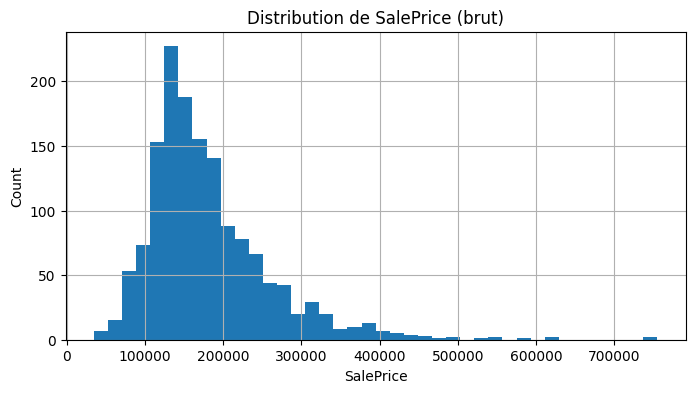

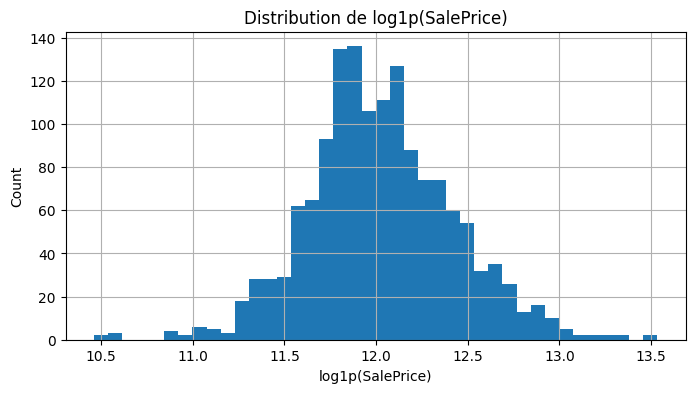

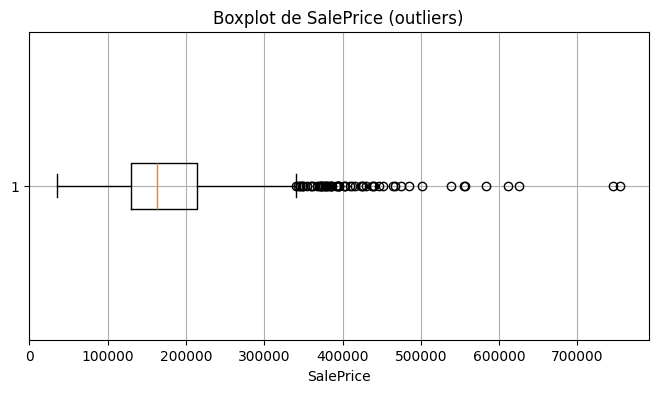

In [ ]:
# 2.3 Distribution de SalePrice + log1p

y_raw = train_df["SalePrice"].copy()
y_log = np.log1p(y_raw)

print("SalePrice (euros/dollars dataset) stats:")
display(y_raw.describe().to_frame().T)

print("Skewness SalePrice:", round(y_raw.skew(), 3))
print("Skewness log1p(SalePrice):", round(y_log.skew(), 3))

# Histogrammes
plt.figure()
plt.hist(y_raw, bins=40)
plt.title("Distribution de SalePrice (brut)")
plt.xlabel("SalePrice")
plt.ylabel("Count")
plt.show()

plt.figure()
plt.hist(y_log, bins=40)
plt.title("Distribution de log1p(SalePrice)")
plt.xlabel("log1p(SalePrice)")
plt.ylabel("Count")
plt.show()

# Boxplot simple (détection outliers visuels)
plt.figure()
plt.boxplot(y_raw, vert=False)
plt.title("Boxplot de SalePrice (outliers)")
plt.xlabel("SalePrice")
plt.show()


## 2.4 Corrélations (variables numériques)

But :
- repérer les variables numériques les plus liées au prix
- détecter des incohérences (ex: valeurs aberrantes)

**Note** : Corrélation ≠ causalité, mais c’est très utile pour l’exploration.


Top 15 corrélations (en valeur absolue) avec SalePrice:


,corr,abs_corr
OverallQual,0.790982,0.790982
GrLivArea,0.708624,0.708624
GarageCars,0.640409,0.640409
GarageArea,0.623431,0.623431
TotalBsmtSF,0.613581,0.613581
1stFlrSF,0.605852,0.605852
FullBath,0.560664,0.560664
TotRmsAbvGrd,0.533723,0.533723
YearBuilt,0.522897,0.522897
YearRemodAdd,0.507101,0.507101


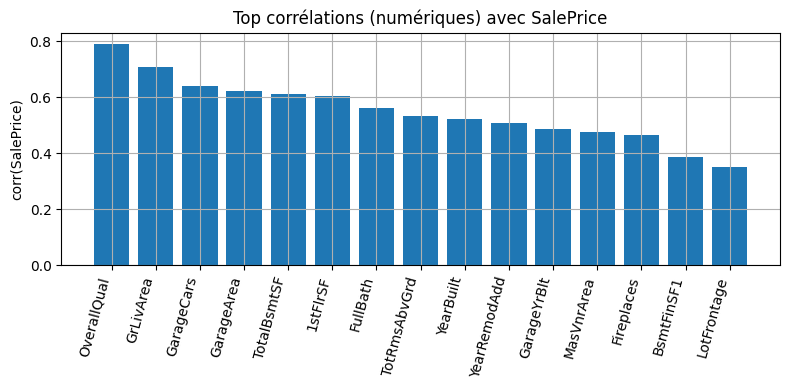

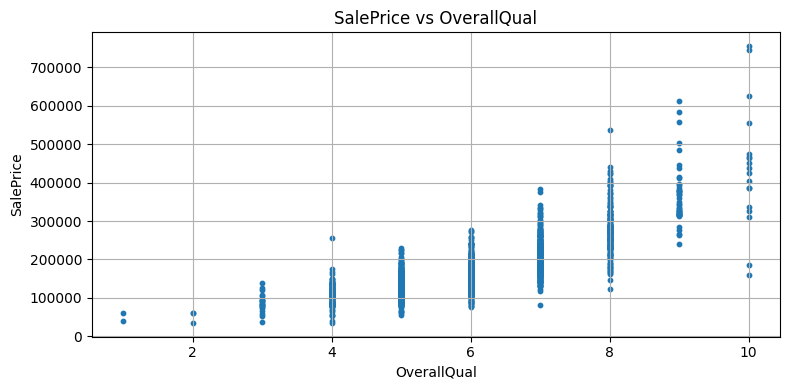

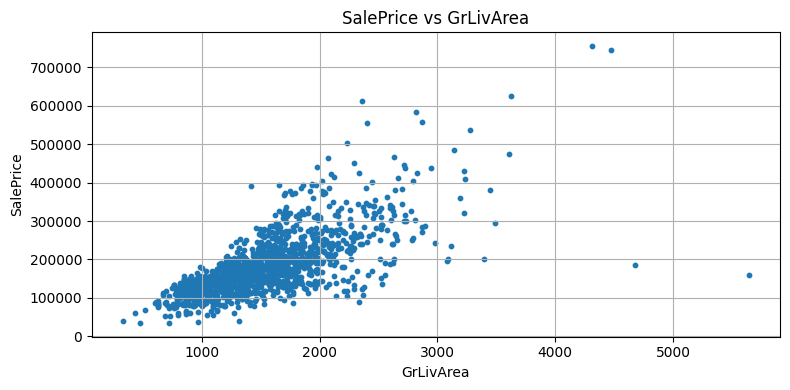

In [ ]:
# 2.4 Corrélations numériques vs SalePrice (train only)

# Sélection automatique des colonnes numériques (train)
numeric_cols_auto = train_df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols_auto = [c for c in numeric_cols_auto if c not in ["Id", "SalePrice"]]

corr = train_df[numeric_cols_auto + ["SalePrice"]].corr(numeric_only=True)["SalePrice"].drop("SalePrice")
corr_abs = corr.abs().sort_values(ascending=False)

print("Top 15 corrélations (en valeur absolue) avec SalePrice:")
display(pd.DataFrame({
    "corr": corr.loc[corr_abs.index].head(15),
    "abs_corr": corr_abs.head(15)
}))

# Bar plot top corr
topn = 15
top_features = corr_abs.head(topn).index.tolist()
plt.figure()
plt.bar(range(topn), corr.loc[top_features].values)
plt.xticks(range(topn), top_features, rotation=75, ha="right")
plt.title("Top corrélations (numériques) avec SalePrice")
plt.ylabel("corr(SalePrice)")
plt.tight_layout()
plt.show()

# Scatter plots pour 2 variables (les plus corrélées)
for feat in top_features[:2]:
    plt.figure()
    plt.scatter(train_df[feat], train_df["SalePrice"], s=10)
    plt.title(f"SalePrice vs {feat}")
    plt.xlabel(feat)
    plt.ylabel("SalePrice")
    plt.tight_layout()
    plt.show()


## 2.5 Analyse catégorielle (effet des catégories sur le prix)

Ici on regarde des variables typiquement très informatives :
- `Neighborhood`
- `KitchenQual`
- `ExterQual`
- `BsmtQual`
- `GarageFinish`

On affiche la **moyenne** et la **médiane** de SalePrice par catégorie.  
Cela aide à justifier :
- OneHotEncoder (nominal)
- Ordinal encoding (quand il y a un ordre naturel: Fa < TA < Gd < Ex)



--- Neighborhood ---


,count,mean,median
Neighborhood,,,
NoRidge,41,335295.317073,301500.0
NridgHt,77,316270.623377,315000.0
StoneBr,25,310499.000000,278000.0
Timber,38,242247.447368,228475.0
Veenker,11,238772.727273,218000.0
Somerst,86,225379.837209,225500.0
ClearCr,28,212565.428571,200250.0
Crawfor,51,210624.725490,200624.0
CollgCr,150,197965.773333,197200.0


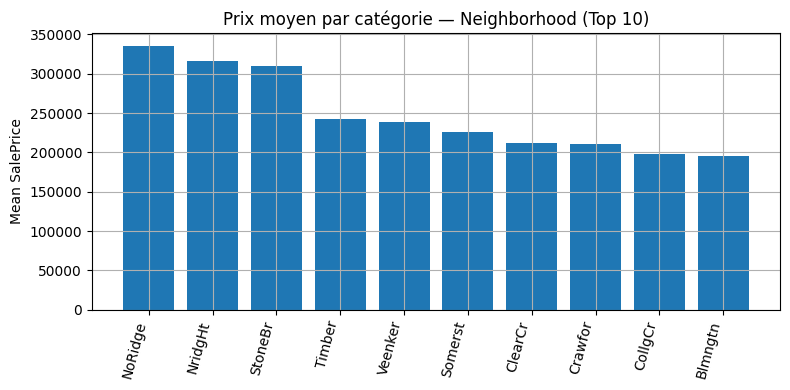


--- KitchenQual ---


,count,mean,median
KitchenQual,,,
Ex,100,328554.670000,316750.0
Gd,586,212116.023891,201400.0
TA,735,139962.511565,137000.0
Fa,39,105565.205128,115000.0


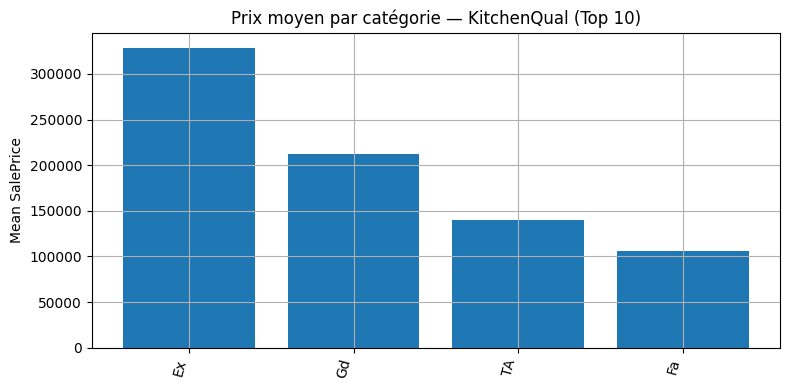


--- ExterQual ---


,count,mean,median
ExterQual,,,
Ex,52,367360.961538,364606.5
Gd,488,231633.510246,220000.0
TA,906,144341.313466,139450.0
Fa,14,87985.214286,82250.0


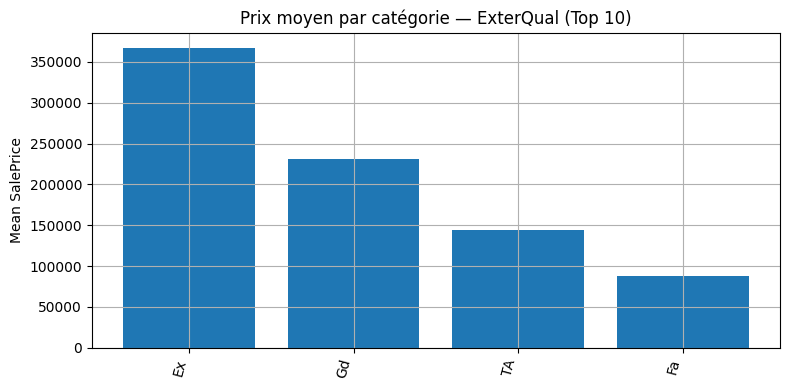


--- BsmtQual ---


,count,mean,median
BsmtQual,,,
Ex,121,327041.041322,318000.0
Gd,618,202688.478964,192070.0
TA,649,140759.818182,135500.0
Fa,35,115692.028571,112000.0
NaN,37,105652.891892,101800.0


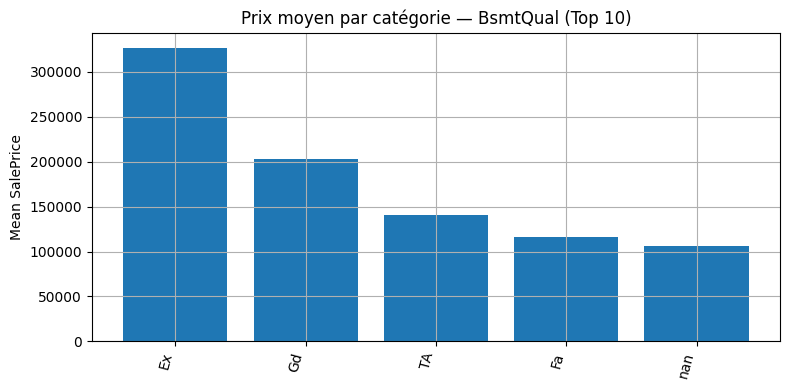


--- GarageFinish ---


,count,mean,median
GarageFinish,,,
Fin,352,240052.690341,215000.0
RFn,422,202068.869668,190000.0
Unf,605,142156.423140,135000.0
NaN,81,103317.283951,100000.0


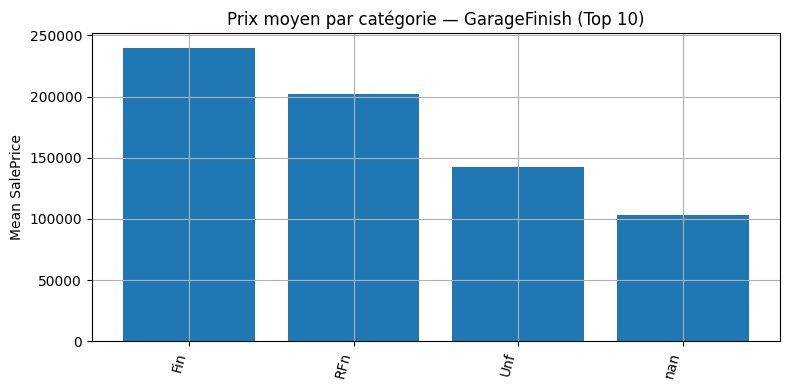


--- SaleCondition ---


,count,mean,median
SaleCondition,,,
Partial,125,272291.752000,244600.0
Normal,1198,175202.219533,160000.0
Alloca,12,167377.416667,148145.0
Family,20,149600.000000,140500.0
Abnorml,101,146526.623762,130000.0
AdjLand,4,104125.000000,104000.0


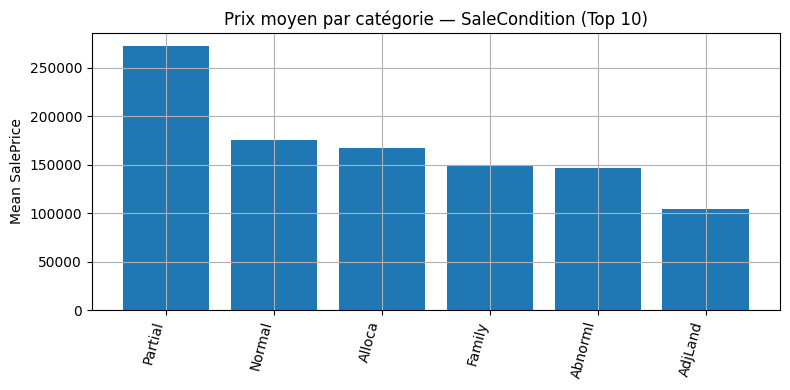


--- MSZoning ---


,count,mean,median
MSZoning,,,
FV,65,214014.061538,205950.0
RL,1151,191004.994787,174000.0
RH,16,131558.375000,136500.0
RM,218,126316.830275,120500.0
C (all),10,74528.000000,74700.0


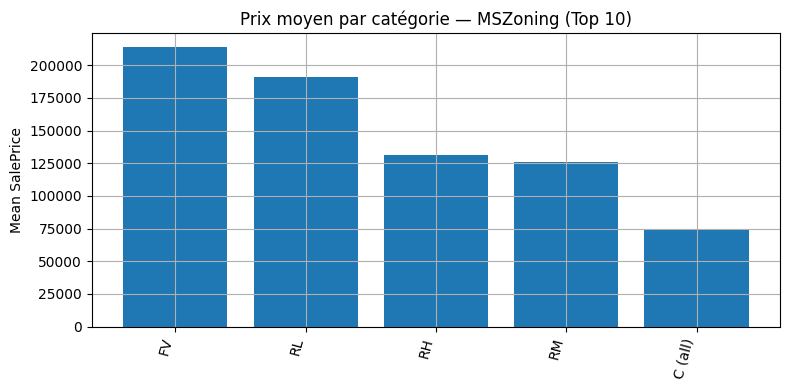

In [ ]:
cat_candidates = ["Neighborhood", "KitchenQual", "ExterQual", "BsmtQual", "GarageFinish", "SaleCondition", "MSZoning"]

for col in cat_candidates:
    if col in train_df.columns:
        grp = (train_df.groupby(col, dropna=False)["SalePrice"]
               .agg(["count", "mean", "median"])
               .sort_values("mean", ascending=False))
        print(f"\n--- {col} ---")
        display(grp.head(15))

        # Plot des 10 meilleures catégories par moyenne
        top = grp.head(10)
        plt.figure()
        plt.bar(range(len(top)), top["mean"].values)
        plt.xticks(range(len(top)), top.index.astype(str), rotation=75, ha="right")
        plt.title(f"Prix moyen par catégorie — {col} (Top 10)")
        plt.ylabel("Mean SalePrice")
        plt.tight_layout()
        plt.show()


## 2.6 Vérification de cohérence Train vs Test

Comme tu as un `train` et un `test`, on vérifie :
- si le test contient des **catégories jamais vues** dans le train
- si certaines variables numériques ont des distributions très différentes

⚠️ Ce n’est pas “tricher” : on n’utilise **pas** `SalePrice` du test (qui n’existe pas), on vérifie seulement la qualité des features.


In [ ]:
# 2.6 Train vs Test: catégories nouvelles + check distributions

# 1) Catégories jamais vues
cat_cols_auto = train_df.select_dtypes(include=["object"]).columns.tolist()

unseen_report = []
for col in cat_cols_auto:
    train_cats = set(train_df[col].dropna().unique())
    test_cats  = set(test_df[col].dropna().unique())
    unseen = sorted(list(test_cats - train_cats))
    if len(unseen) > 0:
        unseen_report.append((col, len(unseen), unseen[:10]))

unseen_df = pd.DataFrame(unseen_report, columns=["column", "n_unseen_in_test", "examples"])
print("Colonnes avec catégories NON vues dans le train (mais présentes dans test):")
display(unseen_df.sort_values("n_unseen_in_test", ascending=False).head(20))

# 2) Check distributions sur quelques num features (moyenne/std)
num_cols_auto = train_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols_auto = [c for c in num_cols_auto if c not in ["Id", "SalePrice"]]

stats_train = train_df[num_cols_auto].describe().T[["mean", "std"]]
stats_test  = test_df[num_cols_auto].describe().T[["mean", "std"]]

delta = (stats_test["mean"] - stats_train["mean"]).abs()
compare = pd.DataFrame({
    "train_mean": stats_train["mean"],
    "test_mean": stats_test["mean"],
    "abs_mean_diff": delta,
    "train_std": stats_train["std"],
    "test_std": stats_test["std"],
}).sort_values("abs_mean_diff", ascending=False)

print("Top 15 variables numériques avec plus grande différence de moyenne (|test-train|):")
display(compare.head(15))


Colonnes avec catégories NON vues dans le train (mais présentes dans test):


,column,n_unseen_in_test,examples


Top 15 variables numériques avec plus grande différence de moyenne (|test-train|):


,train_mean,test_mean,abs_mean_diff,train_std,test_std
LotArea,10516.828082,9819.161069,697.667013,9981.264932,4955.517327
GrLivArea,1515.463699,1486.045922,29.417777,525.480383,485.566099
2ndFlrSF,346.992466,325.967786,21.024680,436.528436,420.610226
MiscVal,43.489041,58.167923,14.678882,496.123024,630.806978
BsmtUnfSF,567.240411,554.294925,12.945486,441.866955,437.260486
TotalBsmtSF,1057.429452,1046.117970,11.311482,438.705324,442.898624
1stFlrSF,1162.626712,1156.534613,6.092100,386.587738,398.165820
BsmtFinSF2,46.549315,52.619342,6.070026,161.319273,176.753926
BsmtFinSF1,443.639726,439.203704,4.436022,456.098091,455.268042
MasVnrArea,103.685262,100.709141,2.976120,181.066207,177.625900


## 3) Définition des colonnes par type

In [ ]:
# Colonnes numériques continues
num_continuous = [
    'LotFrontage', 'LotArea', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
    'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
    'GrLivArea', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch',
    '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'GarageYrBlt'
]

# Colonnes numériques discrètes (pas besoin de scaling)
num_discrete = [
    'MSSubClass','OverallQual','OverallCond','YearBuilt','YearRemodAdd',
    'BsmtFullBath','BsmtHalfBath','FullBath','HalfBath','BedroomAbvGr',
    'KitchenAbvGr','TotRmsAbvGrd','Fireplaces','GarageCars','MoSold','YrSold'
]

# Colonnes catégorielles nominales
cat_nominal = [
    'MSZoning','Street','Alley','LotShape','LandContour','Utilities','LotConfig',
    'LandSlope','Neighborhood','Condition1','Condition2','BldgType','HouseStyle',
    'RoofStyle','RoofMatl','Exterior1st','Exterior2nd','MasVnrType','Foundation',
    'Heating','CentralAir','Electrical','GarageType','GarageFinish','PavedDrive',
    'Fence','MiscFeature','SaleType','SaleCondition'
]

# Colonnes catégorielles ordinales
cat_ordinal = [
    'ExterQual','ExterCond','BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1',
    'BsmtFinType2','HeatingQC','KitchenQual','Functional','FireplaceQu',
    'GarageQual','GarageCond','PoolQC'
]


## 4) Mappings ordinales

In [ ]:
# Ces variables ont un ordre naturel : Ex > Gd > TA > Fa > Po > None
qual_map = {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}

# Exposition du sous-sol : Gd > Av > Mn > No > None
exposure_map = {"None": 0, "No": 1, "Mn": 2, "Av": 3, "Gd": 4}

# Type de finition sous-sol : GLQ (meilleur) > ... > Unf > None
bsmttype_map = {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6}

# Fonctionnalité : Typ (meilleur) > ... > Sev > None
functional_map = {"None": 0, "Sev": 1, "Maj2": 2, "Maj1": 3, "Mod": 4, "Min1": 5, "Min2": 6, "Typ": 7}


## 5) Transformer pour encoder les ordinales

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin

class OrdinalMapper(BaseEstimator, TransformerMixin):
    def __init__(self, mappings):
        self.mappings = mappings

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_copy = X.copy()
        for col, map_dict in self.mappings.items():
            X_copy[col] = X_copy[col].fillna('None')
            X_copy[col] = X_copy[col].map(map_dict)
        return X_copy

## 6) Preprocessing (ColumnTransformer + Pipelines)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# Pipeline pour les numériques continus
num_cont_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # Remplace NaN par médiane
    ('scaler', StandardScaler())
])

# Pipeline pour les numériques discrets (pas de scaling)
num_disc_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

# Pipeline pour les nominales
cat_nom_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
])

# Pipeline pour les ordinales
cat_ord_pipeline = Pipeline([
    ('mapper', OrdinalMapper({
        'ExterQual': qual_map, 'ExterCond': qual_map,
        'BsmtQual': qual_map, 'BsmtCond': qual_map,
        'BsmtExposure': exposure_map,
        'BsmtFinType1': bsmttype_map, 'BsmtFinType2': bsmttype_map,
        'HeatingQC': qual_map, 'KitchenQual': qual_map,
        'Functional': functional_map,
        'FireplaceQu': qual_map,
        'GarageQual': qual_map, 'GarageCond': qual_map,
        'PoolQC': qual_map
    }))
])

preprocessor = ColumnTransformer(transformers=[
    ('num_cont', num_cont_pipeline, num_continuous),
    ('num_disc', num_disc_pipeline, num_discrete),
    ('cat_nom', cat_nom_pipeline, cat_nominal),
    ('cat_ord', cat_ord_pipeline, cat_ordinal)
],
    remainder="drop" )


## 7) Fonction RMSE(log) en Cross-Validation

Cette fonction permet d’évaluer la performance d’un modèle de régression en utilisant la
**RMSE calculée sur le logarithme de la variable cible**, dans un cadre de **validation croisée**.

La transformation `log1p(y)` est appliquée afin de :
- réduire l’asymétrie de la variable cible,
- limiter l’influence des maisons très chères,
- mesurer une **erreur relative** plutôt qu’absolue.

La validation croisée K-Fold divise les données en plusieurs sous-ensembles :
à chaque itération, le modèle est entraîné sur une partie des données et évalué sur une autre,
ce qui fournit une estimation plus fiable de la performance et limite le sur-apprentissage.

La métrique utilisée est la **RMSE**, qui pénalise davantage les grandes erreurs.
Le score retourné par `scikit-learn` étant négatif par convention, la fonction renvoie
la moyenne des scores avec un signe positif pour une interprétation directe.


In [ ]:
def rmse_log_cv(pipeline, X, y, cv_splits=5):
    """RMSE sur log1p(y) via CV."""
    y_log = np.log1p(y)
    cv = KFold(n_splits=cv_splits, shuffle=True, random_state=42)

    scores = cross_val_score(
        pipeline,
        X,
        y_log,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=-1
    )
    return -scores.mean()


## 8) Baselines : comparaison de modèles

Cette étape consiste à comparer plusieurs **modèles de référence (baselines)** afin
d’identifier ceux qui capturent le mieux la relation entre les variables explicatives
et le prix des maisons.

L’objectif n’est pas encore d’optimiser finement les modèles, mais de :
- évaluer différentes familles d’algorithmes (linéaires, régularisés, arbres, boosting),
- comparer leurs performances sur une **métrique commune (RMSE(log))**,
- analyser leur capacité de généralisation via la **cross-validation**.

In [ ]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001, max_iter=10000),
    "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000),
    "RandomForest": RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=1000, learning_rate=0.03, num_leaves=31, subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=-1)
}

results = {}
for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    score = rmse_log_cv(pipe, X, y, cv_splits=5)
    results[name] = score
    print(f"{name}: RMSE(log) CV = {score:.4f}")

print("\n=== Top modèles ===")
for k, v in sorted(results.items(), key=lambda x: x[1])[:8]:
    print(f"{k}: {v:.4f}")


LinearRegression: RMSE(log) CV = 0.1493
Ridge: RMSE(log) CV = 0.1437
Lasso: RMSE(log) CV = 0.1441
ElasticNet: RMSE(log) CV = 0.1416
RandomForest: RMSE(log) CV = 0.1442
GradientBoosting: RMSE(log) CV = 0.1300
XGBoost: RMSE(log) CV = 0.1330
LightGBM: RMSE(log) CV = 0.1339

=== Top modèles ===
GradientBoosting: 0.1300
XGBoost: 0.1330
LightGBM: 0.1339
ElasticNet: 0.1416
Ridge: 0.1437
Lasso: 0.1441
RandomForest: 0.1442
LinearRegression: 0.1493


## 9) Tuning des hyperparamètres (GridSearchCV)

Le **tuning des hyperparamètres** consiste à **chercher automatiquement la meilleure combinaison de paramètres** d’un modèle afin d’améliorer ses performances de généralisation.

Contrairement aux paramètres appris pendant l’entraînement (poids, seuils), les **hyperparamètres** sont fixés **avant** l’apprentissage et contrôlent le comportement du modèle (complexité, vitesse d’apprentissage, régularisation).

#### Rôle de GridSearchCV

`GridSearchCV` teste **systématiquement toutes les combinaisons possibles** d’un ensemble d’hyperparamètres définis dans une grille.  
Pour chaque combinaison :
- le modèle est entraîné,
- évalué par **cross-validation**,
- noté à l’aide de la métrique choisie (ici RMSE(log)).

À la fin :
- la combinaison donnant le **meilleur score moyen** est sélectionnée,
- le modèle final est automatiquement **ré-entraîné sur l’ensemble des données d’entraînement** avec ces paramètres optimaux.

#### Pourquoi utiliser la cross-validation dans le tuning ?

- obtenir une estimation **stable et robuste** des performances,
- éviter d’optimiser les paramètres sur un seul split,
- réduire le risque de sur-ajustement.

#### Résultat du tuning

Le tuning permet :
- d’augmenter la précision du modèle,
- d’améliorer la capacité de généralisation,
- de trouver un **compromis optimal biais / variance**.

#### Pourquoi on fait le tuning *après* le choix de l’algorithme ?

On commence par comparer plusieurs familles de modèles avec des réglages “raisonnables”.
Une fois qu’un modèle ressort meilleur (ici **GradientBoosting**), on **tune** ses hyperparamètres.

Avantage :
- on évite de passer beaucoup de temps à tuner un modèle qui n’est pas compétitif
- on réduit le risque d’overfitting “par recherche” sur trop de modèles

---

#### Explication des hyperparamètres (GradientBoosting)

- `n_estimators` : nombre d’arbres (plus = plus puissant, mais plus long)
- `learning_rate` : taille du pas d’apprentissage (plus petit = plus stable, souvent meilleur)
- `max_depth` : profondeur des arbres (plus grand = plus complexe, risque d’overfit)
- `subsample` : fraction de données utilisée par arbre (souvent < 1 améliore la généralisation)

**Règle générale :**
`learning_rate` petit + `n_estimators` plus grand + `max_depth` modéré → bon compromis.

In [ ]:
final_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

param_grid = {
    "model__n_estimators": [200, 300, 500],
    "model__learning_rate": [0.03, 0.05, 0.08],
    "model__max_depth": [2, 3, 4],
    "model__subsample": [0.8, 1.0]
}

grid = GridSearchCV(
    final_pipeline,
    param_grid,
    scoring="neg_root_mean_squared_error",   # RMSE sur y_log
    cv=5,
    n_jobs=-1
)

y_log = np.log1p(y)
grid.fit(X, y_log)

print("Meilleurs paramètres :", grid.best_params_)
print("Meilleur RMSE(log) :", -grid.best_score_)

best_pipeline = grid.best_estimator_

Meilleurs paramètres : {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 500, 'model__subsample': 1.0}
Meilleur RMSE(log) : 0.12003209639519526


## 10) Entraînement final

À cette étape, on **entraîne définitivement le meilleur modèle** avec les hyperparamètres optimisés.

Après la comparaison des modèles et le tuning, le pipeline complet est **ré-entraîné sur tout le jeu d’entraînement** afin d’utiliser l’ensemble des données disponibles.

In [ ]:
best_pipeline.fit(X, np.log1p(y))

test_pred_log = best_pipeline.predict(test_df)
test_pred = np.expm1(test_pred_log)

submission = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": test_pred
})

submission.head()


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


,Id,SalePrice
0,1461,120588.130028
1,1462,162976.217110
2,1463,188566.118484
3,1464,189631.872954
4,1465,187795.299156


# Rapport — Projet de Machine Learning  
## Prédiction du prix des maisons à partir de données immobilières

---

## 1. Introduction

La prédiction des prix immobiliers constitue un problème central en data science appliquée,
avec des enjeux économiques importants pour les particuliers, les agences immobilières et les institutions financières.
Le prix d’un bien dépend de nombreux facteurs hétérogènes : caractéristiques physiques, localisation, qualité de construction
ou encore équipements disponibles.

L’objectif de ce projet est de **construire un modèle de Machine Learning capable de prédire le prix de vente d’une maison**
à partir de variables numériques et catégorielles décrivant le bien.

Ce problème relève de la **régression supervisée**, car :
- la variable cible est continue (prix de vente),
- les données d’entraînement contiennent à la fois les variables explicatives et la cible,
- le but est d’apprendre une fonction reliant ces variables au prix.

---

## 2. Description du jeu de données

Le jeu de données est composé de deux parties :
- un **jeu d’entraînement (train)** contenant la variable cible `SalePrice`,
- un **jeu de test (test)** ne contenant que les variables explicatives.

Chaque observation représente une maison décrite par **81 variables**, incluant :
- des variables **numériques** (surface, nombre de pièces, année de construction, etc.),
- des variables **catégorielles** (type de quartier, qualité des matériaux, type de garage, etc.).

### Valeurs manquantes

Certaines variables contiennent un nombre important de valeurs manquantes.
Ces valeurs ne sont pas toujours dues à une absence de mesure, mais souvent à une **absence réelle de l’élément** :
- absence de garage,
- absence de sous-sol,
- absence de piscine.

Il est donc essentiel de traiter ces valeurs avec une interprétation métier adaptée.

---

## 3. Analyse Exploratoire des Données (EDA)

### 3.1 Analyse de la variable cible

L’étude de la variable `SalePrice` montre :
- une distribution fortement **asymétrique à droite**,
- la présence de **valeurs extrêmes** correspondant à des maisons très chères.

Cette asymétrie peut nuire aux modèles de régression, car les grandes valeurs dominent l’apprentissage.

### 3.2 Transformation logarithmique

Pour corriger ce problème, une transformation `log1p(SalePrice)` est appliquée :
- elle réduit l’asymétrie de la distribution,
- elle stabilise la variance,
- elle permet d’interpréter les erreurs de manière **relative** plutôt qu’absolue.

Mathématiquement, cette transformation revient à minimiser les erreurs proportionnelles plutôt que les erreurs en euros bruts.

### 3.3 Corrélations et variables influentes

L’analyse des corrélations montre que :
- les surfaces habitables,
- la qualité globale,
- l’année de construction

ont un impact fort sur le prix.

Les variables catégorielles liées à la **qualité** jouent également un rôle majeur.

---

## 4. Prétraitement des données

L’objectif du prétraitement est de transformer des données brutes en données exploitables par les algorithmes.

### 4.1 Gestion des valeurs manquantes

Deux stratégies sont utilisées :
- **imputation par la médiane** pour les variables numériques,
- **imputation par le mode ou une catégorie “None”** pour les variables catégorielles.

Lorsque le NaN représente une absence réelle (garage, piscine), cette information est conservée.

### 4.2 Encodage des variables catégorielles

- **Encodage ordinal** pour les variables de qualité (ordre logique),
- **One-Hot Encoding** pour les variables nominales sans ordre.

### 4.3 Standardisation

Les variables numériques sont standardisées afin de :
- faciliter la convergence des modèles linéaires,
- rendre les coefficients comparables,
- améliorer la stabilité numérique.

L’ensemble de ces étapes est intégré dans un **pipeline** afin d’éviter toute fuite de données.

---

## 5. Choix des métriques d’évaluation

Plusieurs métriques existent pour évaluer un modèle de régression :
- MSE (Mean Squared Error),
- RMSE (Root Mean Squared Error),
- RMSE(log).

### 5.1 Pourquoi RMSE(log) ?

Le RMSE classique pénalise fortement les erreurs sur les maisons chères.
Ainsi, une erreur de 20 000 € n’a pas le même impact pour une maison à 100 000 € que pour une maison à 500 000 €.

Le **RMSE(log)** :
- mesure des erreurs relatives,
- limite la dominance des valeurs élevées,
- est plus cohérent avec l’objectif métier.

---

## 6. Modèles utilisés

Plusieurs familles de modèles sont testées :

- Régression linéaire (baseline simple),
- Ridge, Lasso, ElasticNet (régularisation),
- Random Forest (modèle non linéaire),
- Gradient Boosting,
- XGBoost,
- LightGBM.

Cette diversité permet de comparer :
- des modèles simples vs complexes,
- des approches biaisées vs flexibles,
- des méthodes linéaires vs non linéaires.

---

## 7. Validation par cross-validation

La performance des modèles est évaluée via une **cross-validation K-Fold**.

Cette méthode permet :
- d’obtenir une estimation robuste des performances,
- de réduire la dépendance à un seul découpage train/validation,
- d’analyser la capacité de généralisation.

---

## 8. Comparaison des modèles (Baselines)

Les modèles sont comparés selon leur **RMSE(log) moyen en cross-validation**.

Cette étape permet :
- d’identifier les modèles sous-performants,
- de sélectionner les modèles les plus prometteurs,
- de préparer le choix du modèle final.

---

## 9. Tuning des hyperparamètres

Une fois le meilleur modèle identifié, ses hyperparamètres sont optimisés via **GridSearchCV**.

Cette méthode teste plusieurs combinaisons de paramètres et sélectionne celle qui maximise la performance moyenne en cross-validation.

Le tuning permet :
- d’améliorer la précision,
- de contrôler la complexité,
- de trouver un bon compromis biais / variance.

---

## 10. Entraînement final

Le modèle final est ré-entraîné sur **l’ensemble du jeu d’entraînement** avec les hyperparamètres optimaux.

Cette étape permet :
- d’exploiter toutes les données disponibles,
- d’obtenir un modèle stable,
- de préparer l’utilisation finale du modèle.

---

## 11. Interprétation métier

Le RMSE(log) obtenu peut être interprété comme une **erreur relative moyenne**.
Cela signifie que, en moyenne, la prédiction s’écarte du prix réel d’un certain pourcentage,
ce qui est plus pertinent qu’une erreur fixe en euros.

---

## 12. Conclusion

Ce projet a permis de :
- mettre en œuvre un pipeline complet de Machine Learning,
- comparer différentes familles de modèles,
- comprendre l’impact du prétraitement et des métriques,
- construire un modèle robuste et généralisable.

### Perspectives
- Feature engineering avancé,
- modèles d’ensemble (stacking),
- interprétabilité (SHAP, feature importance).

Ce travail illustre une démarche rigoureuse et reproductible,
conforme aux standards académiques et industriels.
